In [1]:
library(dplyr)
library(Matrix)
library(data.table)
library(Seurat)
library(ggplot2)
library(RColorBrewer)
library(cowplot)
library(future)
library(viridis)
library(SeuratObject)
library(tidyr)
plan("multicore", workers = 16)
options(future.globals.maxSize = 100 * 1024^3)
library(ComplexHeatmap)
cols = c(brewer.pal(9, "Set1"),brewer.pal(8,"Set2")[1:8],brewer.pal(12,"Paired")[1:12],brewer.pal(8,"Dark2")[1:8],brewer.pal(8,"Accent"),brewer.pal(12, "Set3"),brewer.pal(9,"Pastel1"),brewer.pal(8,"Pastel2"))
cols = c(cols,cols)
library(pheatmap)

Warning message:
“package ‘dplyr’ was built under R version 4.2.3”

Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Warning message:
“package ‘Matrix’ was built under R version 4.2.3”

Attaching package: ‘data.table’


The following objects are masked from ‘package:dplyr’:

    between, first, last


The legacy packages maptools, rgdal, and rgeos, underpinning this package
will retire shortly. Please refer to R-spatial evolution reports on
https://r-spatial.org/r/2023/05/15/evolution4.html for details.
This package is now running under evolution status 0 

Attaching SeuratObject

Warning message:
“package ‘ggplot2’ was built under R version 4.2.3”
Warning message:
“package ‘viridis’ was built under R version 4.2.3”
Loading required package: viridisLite


Attaching package: ‘tidyr’


The following objects are masked from ‘package:Matrix’

In [2]:
outpath = "/data/sublayer"

In [19]:
seuobj = readRDS(paste0("/data/Bin200.merge.seuobj.rds"))

In [ ]:
### Calculating the proportional representation of Bayesian results at various resolutions within the `anno_layer`.

In [107]:
#Plot：Sort the data and visualize it as a diagonal heatmap.
reorder_matrix <- function(matrix1, by.rows = TRUE) {
  if (by.rows == TRUE) {
    conf.order <- order(apply(matrix1, 1, which.max))
    matrix1.reordered <- matrix1[conf.order, ]
  } else {
    conf.order <- order(apply(matrix1, 2, which.max))
    matrix1.reordered <- matrix1[, conf.order]
  }
}

In [178]:
#Calculate the proportion of cell types within each cluster.
cell2cluster = table(seuobj$area, seuobj$`Bayes17`)
cell2cluster = as.data.frame(cell2cluster)
colnames(cell2cluster) = c("Layer","Cluster","Num")
### long2wide
cell2cluster = spread(cell2cluster,Cluster,Num)
#add rownames
rownames(cell2cluster) = cell2cluster$Layer
cell2cluster = cell2cluster[,-1]
## Calculate Proportion
######cell2cluster_Freq = cell2cluster/colSums(cell2cluster)
col_sums = colSums(cell2cluster)
# Initialize the `cell2cluster_Freq` data frame, with column names identical to those of `cell2cluster`.
cell2cluster_Freq <- data.frame(matrix(NA, nrow = nrow(cell2cluster), ncol = ncol(cell2cluster)))
# Use `lapply()` to calculate the frequency of each column.
cell2cluster_Freq <- as.data.frame(lapply(1:ncol(cell2cluster), function(i) {
  cell2cluster[, i] / col_sums[i]
}))
colnames(cell2cluster_Freq) <- colnames(cell2cluster)
rownames(cell2cluster_Freq) <- rownames(cell2cluster)
#### order
cell2cluster_Freq.order = reorder_matrix(cell2cluster_Freq,2)

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


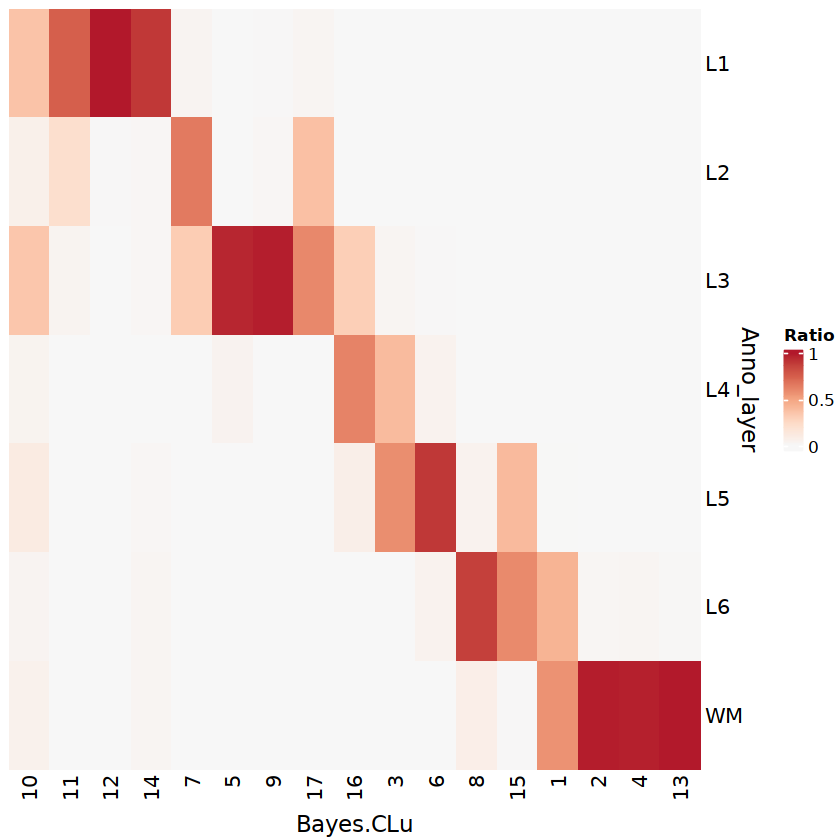

In [179]:
p = Heatmap(cell2cluster_Freq.order, cluster_rows = FALSE, cluster_columns = FALSE,col = rev(brewer.pal(n = 11, name = "RdBu")[2:6]), 
            name = "Ratio",row_title = "Anno_layer", column_title = "Bayes.CLu",column_title_side = "bottom", row_title_side = "right",
           )
p

In [ ]:
Idents(seuobj) = paste0("Bayes16")
### del loWQC cluster
seuobj.sub = subset(seuobj,idents=setdiff(unique(seuobj@meta.data[,paste0("Bayes",i)]),c("10")))

In [86]:
cols =c("#d473d4","#cd1076","#702963",
        "#377eb9",
        "#006400","#4dae48",
        "#974f9f",
        "#cdcd00","#ffff00",
        "#ff7f24","#ffa700",
        "#59260b","#664228","#a65628","#ff8c69")
names(cols) =c("11","12","14",
        "7",
        "5","9",
        "16",
        "3","6",
        "8","15",
        "1","2","4","13")

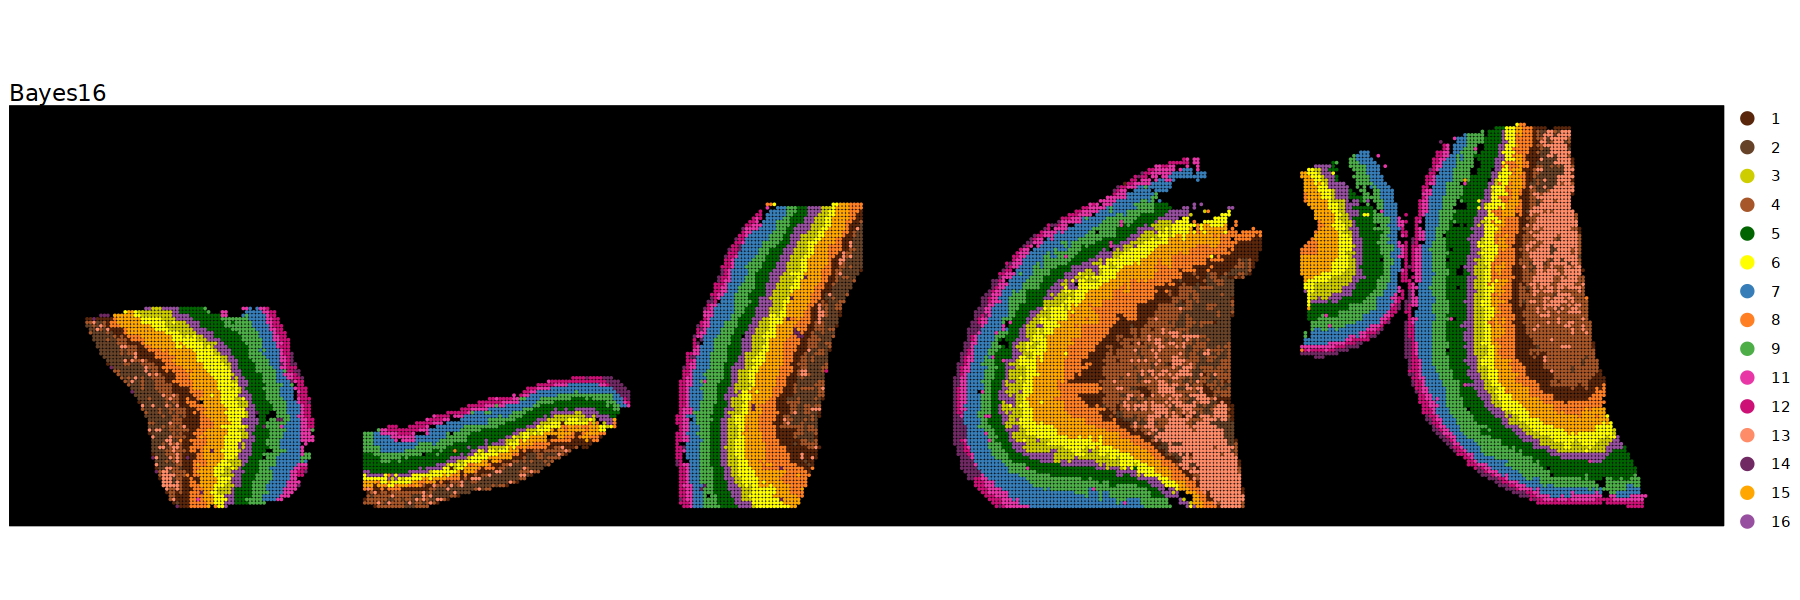

In [87]:
i ="16" 
p = DimPlot(seuobj.sub,reduction="stereo",group.by = paste0("Bayes",i),label = FALSE,label.size = 0.6,pt.size = 0.001,raster=FALSE,cols = cols)+coord_fixed()+ theme_void() +
          theme(axis.text = element_blank(), axis.ticks = element_blank(),axis.title = element_blank(),panel.background = element_rect(fill = "black"))
    print(p)

In [88]:
ggsave(plot=p,"Bin200.Bayes16.subLayer.pdf",width=8)

Saving 8 x 6.67 in image


In [ ]:
## Bayes16 Sublayer Annotation and Plotting

In [28]:
seuobj$sublayer = ""
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "12"),'sublayer'] = "L1_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "14"),'sublayer'] = "L1_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "11"),'sublayer'] = "L1_b"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "7"),'sublayer'] = "L2"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "9"),'sublayer'] = "L3_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "5"),'sublayer'] = "L3_b"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "16"),'sublayer'] = "L4"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "3"),'sublayer'] = "L5_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "6"),'sublayer'] = "L5_b"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "15"),'sublayer'] = "L6_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "8"),'sublayer'] = "L6_b"

seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "1"),'sublayer'] = "WM_a"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "2"),'sublayer'] = "WM"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "4"),'sublayer'] = "WM"
seuobj@meta.data[which(seuobj@meta.data$Bayes16 == "13"),'sublayer'] = "WM"

In [34]:
cols =c("#d473d4","#cd1076",
        "#377eb9",
        "#006400","#4dae48",
        "#974f9f",
        "#cdcd00","#ffff00",
        "#ff7f24","#ffa700",
        "#59260b","#a65628")
names(cols) =c("L1_b","L1_a",
        "L2",
        "L3_a","L3_b",
        "L4",
        "L5_a","L5_b",
        "L6_a","L6_b",
        "WM_a","WM")

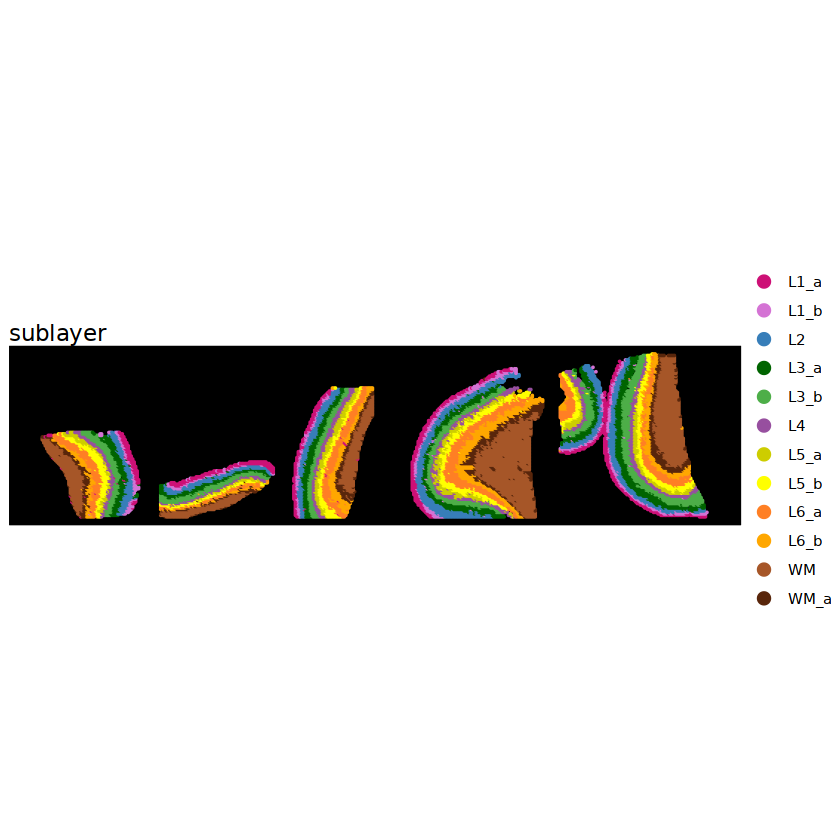

In [35]:
i ="16" 
p = DimPlot(seuobj.sub,reduction="stereo",group.by = paste0("sublayer"),label = FALSE,label.size = 0.6,pt.size = 0.001,raster=FALSE,cols = cols)+coord_fixed()+ theme_void() +
          theme(axis.text = element_blank(), axis.ticks = element_blank(),axis.title = element_blank(),panel.background = element_rect(fill = "black"))
    print(p)

In [36]:
ggsave(plot=p,"Bin200.Bayes16.subLayer.UMAP.pdf",width=8)

Saving 8 x 6.67 in image


In [89]:
### Calculate the proportional composition of clusters in each layer of Bayes16.
##################### Count how many sublayers constitute each layer.

In [37]:
reorder_matrix <- function(matrix1, by.rows = TRUE) {
  if (by.rows == TRUE) {
    conf.order <- order(apply(matrix1, 1, which.max))
    matrix1.reordered <- matrix1[conf.order, ]
  } else {
    conf.order <- order(apply(matrix1, 2, which.max))
    matrix1.reordered <- matrix1[, conf.order]
  }
}

In [ ]:
Idents(seuobj) = paste0("Bayes16")
seuobj.sub = subset(seuobj,idents=setdiff(unique(seuobj@meta.data[,paste0("Bayes",i)]),c("10")))

In [49]:
cell2cluster = table(seuobj.sub$Bayes.anno16, seuobj.sub$sublayer)

cell2cluster = as.data.frame(cell2cluster)
colnames(cell2cluster) = c("Layer","Cluster","Num")
### long2wide
cell2cluster = spread(cell2cluster,Cluster,Num)
#add rownames
rownames(cell2cluster) = cell2cluster$Layer
cell2cluster = cell2cluster[,-1]
cell2cluster = t(cell2cluster)

In [51]:
## Calculate Proportion
######cell2cluster_Freq = cell2cluster/colSums(cell2cluster)
col_sums = colSums(cell2cluster)
# Initialize the `cell2cluster_Freq` data frame, with column names identical to those of `cell2cluster`.
cell2cluster_Freq <- data.frame(matrix(NA, nrow = nrow(cell2cluster), ncol = ncol(cell2cluster)))
# Use `lapply()` to calculate the frequency of each column.
cell2cluster_Freq <- as.data.frame(lapply(1:ncol(cell2cluster), function(i) {
  cell2cluster[, i] / col_sums[i]
}))
colnames(cell2cluster_Freq) <- colnames(cell2cluster)
rownames(cell2cluster_Freq) <- rownames(cell2cluster)

In [52]:
#### order
cell2cluster_Freq.order = reorder_matrix(cell2cluster_Freq,1)

Warning message:
“The input is a data frame-like object, convert it to a matrix.”


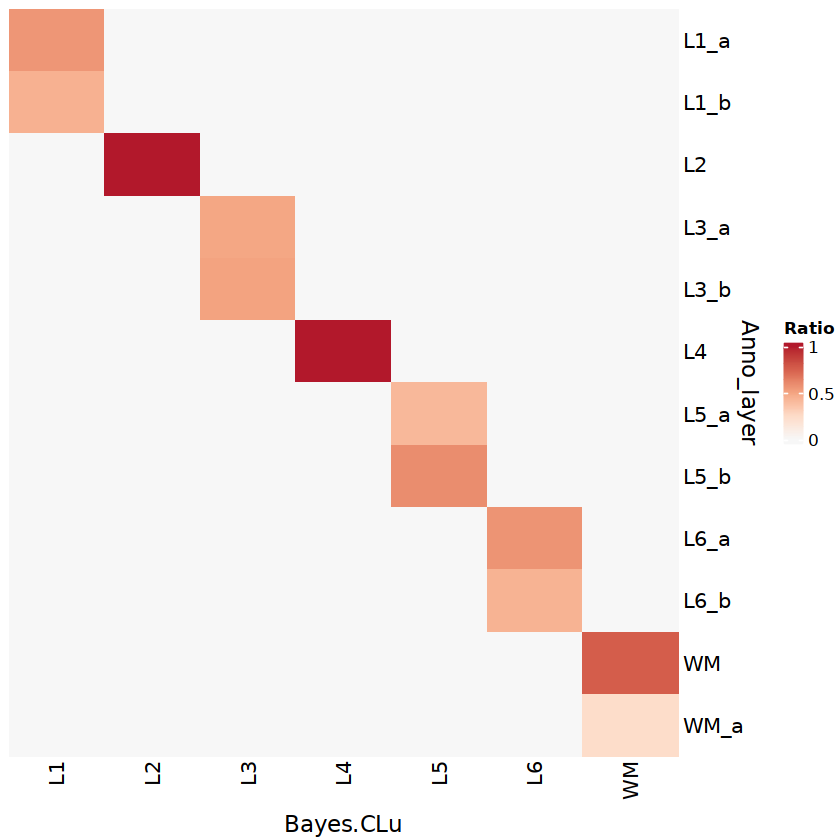

In [53]:
p = Heatmap(cell2cluster_Freq.order, cluster_rows = FALSE, cluster_columns = FALSE,col = rev(brewer.pal(n = 11, name = "RdBu")[2:6]), 
            name = "Ratio",row_title = "Anno_layer", column_title = "Bayes.CLu",column_title_side = "bottom", row_title_side = "right" )
p

In [55]:
pdf("Bin200.Bayes16.annoarea_sublayer.percent.pdf")
print(p)
dev.off()

png 
  2

In [ ]:
saveRDS(seuobj.sub,"/data/Bin200.merge.seuobj.sublayer.rds")